# 12 — LSEG 44-company headline labelling

This notebook registers the headline-level labelling contract for the expanded LSEG robustness corpus. It does **not** pool LSEG with FNSPID and does not inspect returns. The sole automated baseline carried into analysis is the same pinned FinBERT probability margin used in the earlier sector-33 analysis.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr
from sklearn.metrics import cohen_kappa_score
from sentiment_benchmark.artifact_io import sha256_file

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "pyproject.toml").exists():
    raise RuntimeError("run from the repository root or final_experiments/")

COLLECTION = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived/merged"
EXECUTION_SCORES = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_finbert4556_vader_baseline_v1_cacheonly_20260803.csv"
SCORES = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_finbert4556_cacheonly_20260803.csv"
SEED_MANIFEST = EXECUTION_SCORES.with_suffix(EXECUTION_SCORES.suffix + ".seed.json")
EXECUTION_MANIFEST = EXECUTION_SCORES.with_suffix(EXECUTION_SCORES.suffix + ".manifest.json")
SCORE_MANIFEST = SCORES.with_suffix(SCORES.suffix + ".manifest.json")
LLM_SCORES = REPO_ROOT / "Data/collections/lseg_us_sector_44_8m_headlines/derived/headline_scores_gemma4_12b_investor_headline_soft_label_v1_t64.csv"
LLM_MANIFEST = LLM_SCORES.with_suffix(LLM_SCORES.suffix + ".manifest.json")
OUTPUT = REPO_ROOT / "final_experiments/outputs/12_lseg_44_labelling"
OUTPUT.mkdir(parents=True, exist_ok=True)
FINBERT_REVISION = "4556d13015211d73dccd3fdd39d39232506f3e43"
LLM_PROMPT_ID = "investor_headline_soft_label_v1"
LLM_PROMPT_HASH = "81596538d99b29b8"
LLM_MODEL_DIGEST = "4eb23ef187e2c5462566d6a1d3bbbc2f1346d0b4327cbb66d58fffbcc9b2b05c"
SEED = 42


## Frozen estimand and leakage boundary

- **Unit:** one unique normalized headline string; repeated story IDs and duplicate text do not receive extra model calls.
- **Primary output:** `P(positive) - P(negative)` from `ProsusAI/finbert` revision `4556d130…`; hard label is the maximum-probability class.
- **Excluded output:** VADER rows produced by the legacy resumable executor are retained only as inert provenance and are not analysed.
- **Information set:** headline text only. Returns, future stories, bodies, and post-publication fields are unavailable to the scorer.
- **Reuse:** inherit a FinBERT label only when the normalized-headline SHA-256 matches exactly. The execution seed also checked its legacy paired row before reuse, but that row is excluded downstream.
- **Regime:** LSEG remains a separate 2025–2026 robustness arm.


In [2]:
merged = json.loads((COLLECTION / "manifest.json").read_text())
seed = json.loads(SEED_MANIFEST.read_text())
execution_manifest = json.loads(EXECUTION_MANIFEST.read_text()) if EXECUTION_MANIFEST.exists() else None
score_manifest = json.loads(SCORE_MANIFEST.read_text()) if SCORE_MANIFEST.exists() else None

assert merged["status"] == "completed"
assert merged["config"]["collection"]["id"] == "lseg_us_sector_44_8m_headlines"
assert merged["counts"]["symbols"] == 44
assert seed["contract"]["finbert_revision"] == FINBERT_REVISION
assert seed["summary"]["target_unique_headlines"] == 888_155
assert seed["summary"]["reusable_unique_headlines"] == 568_704
assert seed["summary"]["missing_unique_headlines"] == 319_451

if execution_manifest is not None and execution_manifest["status"] == "completed":
    assert execution_manifest["models"]["finbert"]["revision"] == FINBERT_REVISION
    assert execution_manifest["counts"]["finbert_successes"] == 888_155
if score_manifest is not None and score_manifest["status"] == "completed":
    assert score_manifest["contract"]["scorer"] == "finbert"
    assert score_manifest["contract"]["revision"] == FINBERT_REVISION
    assert score_manifest["summary"]["unique_headlines"] == 888_155


## Coverage and run state

Fresh inference is required only for the exact-hash complement of the old sector-33 population. The three old hashes absent from the merged corpus are deliberately not carried forward.


In [3]:
coverage = pd.DataFrame(
    [
        {"status": "inherited exact hash", "unique_headlines": seed["summary"]["reusable_unique_headlines"]},
        {"status": "fresh inference", "unique_headlines": seed["summary"]["missing_unique_headlines"]},
    ]
)
coverage["share"] = coverage["unique_headlines"] / coverage["unique_headlines"].sum()
run_state = "NOT_STARTED" if score_manifest is None else score_manifest["status"].upper()
print(f"label run state: {run_state}")
display(coverage.style.format({"unique_headlines": "{:,.0f}", "share": "{:.2%}"}))
coverage.to_csv(OUTPUT / "labelling_coverage.csv", index=False)


label run state: COMPLETED


,status,unique_headlines,share
0,inherited exact hash,"568,704",64.03%
1,fresh inference,"319,451",35.97%


## Aggregate label diagnostics

These tables are licence-safe aggregates. They are produced only after the FinBERT-only export reports complete coverage. No headline text is displayed or written under `final_experiments/outputs/`.


In [4]:
label_summary = pd.DataFrame()
if score_manifest is not None and score_manifest["status"] == "completed":
    parts = []
    for chunk in pd.read_csv(
        SCORES,
        usecols=["baseline", "label", "score", "status"],
        chunksize=200_000,
    ):
        chunk = chunk.loc[chunk["status"].eq("success")].copy()
        assert chunk["baseline"].eq("finbert").all()
        chunk["score"] = pd.to_numeric(chunk["score"], errors="raise")
        parts.append(
            chunk.groupby(["baseline", "label"], as_index=False).agg(
                rows=("score", "size"), score_sum=("score", "sum")
            )
        )
    label_summary = (
        pd.concat(parts, ignore_index=True)
        .groupby(["baseline", "label"], as_index=False)[["rows", "score_sum"]]
        .sum()
    )
    label_summary["mean_score"] = label_summary["score_sum"] / label_summary["rows"]
    label_summary["label_share"] = label_summary["rows"] / label_summary.groupby("baseline")["rows"].transform("sum")
    assert label_summary.groupby("baseline")["rows"].sum().eq(888_155).all()
    assert label_summary["baseline"].eq("finbert").all()
    label_summary.drop(columns="score_sum").to_csv(OUTPUT / "label_distribution.csv", index=False)
    display(label_summary.drop(columns="score_sum").style.format({"rows": "{:,.0f}", "mean_score": "{:.4f}", "label_share": "{:.2%}"}))
else:
    print("Aggregate diagnostics deferred until the completed score manifest is present locally.")


,baseline,label,rows,mean_score,label_share
0,finbert,negative,"186,812",-0.8156,21.03%
1,finbert,neutral,"411,231",0.0576,46.30%
2,finbert,positive,"290,112",0.7758,32.66%


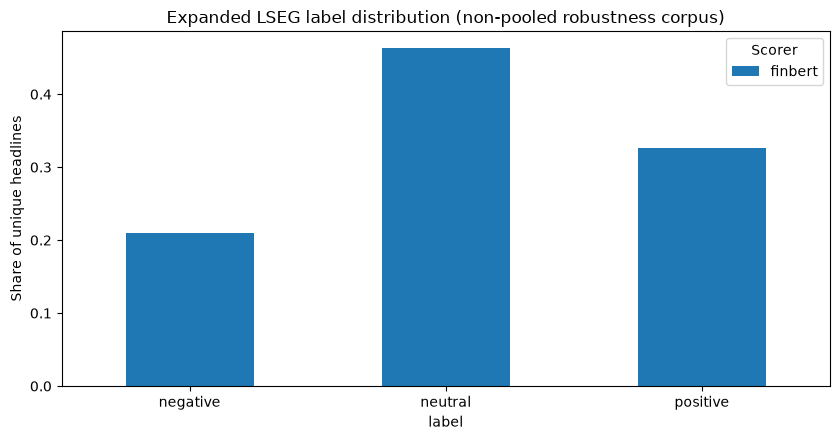

In [5]:
if not label_summary.empty:
    plot = label_summary.pivot(index="label", columns="baseline", values="label_share").fillna(0)
    ax = plot.reindex(["negative", "neutral", "positive"]).plot.bar(figsize=(8.5, 4.5), rot=0)
    ax.set_ylabel("Share of unique headlines")
    ax.set_title("Expanded LSEG label distribution (non-pooled robustness corpus)")
    ax.legend(title="Scorer")
    ax.figure.tight_layout()
    ax.figure.savefig(OUTPUT / "label_distribution.png", dpi=150)
    plt.show()


## Separate LLM scoring arm

A local structured-output LLM is a diagnostic scorer, not a replacement ground truth. The frozen first gate is the first 200 rows in deterministic normalized-headline SHA-256 order, using the existing UCL Ollama `gemma4:12b` path. Hash ordering is independent of company, date, source, and FinBERT label, so the first 1,000 rows form the population-agreement sample without return-based selection. If at least 99% of pilot rows parse successfully without changing model, prompt, temperature, or token budget, extend to a maximum 3,500-headline audit set: those 1,000 rows plus up to 10 rows per company × Reuters/non-Reuters × FinBERT class stratum, deduplicated. Overall estimates use the hash-order component; the balanced component is for subgroup failure analysis.


In [6]:
llm_design = pd.DataFrame(
    [
        {"stage": "format/runtime gate", "maximum_rows": 200, "sampling": "first 200 in deterministic SHA-256 order", "exit_rule": ">=99% valid successful rows", "seed": None},
        {"stage": "population agreement", "maximum_rows": 1_000, "sampling": "first 1,000 in deterministic SHA-256 order", "exit_rule": "report class agreement, kappa, rank correlation", "seed": None},
        {"stage": "subgroup diagnostic", "maximum_rows": 2_640, "sampling": "<=10 per company x source scope x FinBERT class", "exit_rule": "no population-wide claim", "seed": SEED},
        {"stage": "blinded human audit", "maximum_rows": 400, "sampling": "seeded from union; hide model labels", "exit_rule": "accuracy claims require completed human labels", "seed": SEED},
    ]
)
display(llm_design)
llm_design.to_csv(OUTPUT / "llm_scoring_design.csv", index=False)


,stage,maximum_rows,sampling,exit_rule,seed
0,format/runtime gate,200,first 200 in deterministic SHA-256 order,>=99% valid successful rows,NaN
1,population agreement,1000,"first 1,000 in deterministic SHA-256 order","report class agreement, kappa, rank correlation",NaN
2,subgroup diagnostic,2640,<=10 per company x source scope x FinBERT class,no population-wide claim,42.0
3,blinded human audit,400,seeded from union; hide model labels,accuracy claims require completed human labels,42.0


## LLM agreement diagnostics

These are agreement and rank-association estimates on valid rows from the frozen 1,000-headline hash-order sample. Three deterministic format failures remained after an identical resume, leaving n=997. They are retained in provenance rather than silently replaced. These are not accuracy estimates because neither automated scorer is ground truth. No headline text is exported.


In [7]:
llm_metrics = pd.DataFrame()
llm_run_audit = pd.DataFrame()
if LLM_SCORES.exists() and LLM_MANIFEST.exists() and SCORES.exists():
    llm_manifest = json.loads(LLM_MANIFEST.read_text())
    assert llm_manifest["status"] in {"completed", "completed_with_failures"}
    assert llm_manifest["model"] == {"tag": "gemma4:12b", "digest": LLM_MODEL_DIGEST}
    assert llm_manifest["prompt"] == {"id": LLM_PROMPT_ID, "hash": LLM_PROMPT_HASH, "output_mode": "soft_label"}
    assert llm_manifest["inference"]["temperature"] == 0
    assert llm_manifest["inference"]["structured_output"] is True
    assert llm_manifest["inference"]["source_codes"] == []
    assert llm_manifest["inference"]["direct_company_only"] is False
    assert llm_manifest["counts"]["population"] == 888_155
    assert llm_manifest["outputs"]["scores_sha256"] == sha256_file(LLM_SCORES)

    llm_all = pd.read_csv(LLM_SCORES, usecols=["headline_sha256", "label", "score", "status"])
    initial = llm_all.iloc[:1_000]
    assert len(initial) == 1_000
    llm = llm_all.loc[llm_all["status"].eq("success")].drop(columns="status")
    assert initial["status"].eq("success").mean() >= 0.99
    assert len(llm) == 997 and llm["headline_sha256"].is_unique
    llm_run_audit = pd.DataFrame([
        {"metric": "initial attempts", "value": len(initial)},
        {"metric": "initial valid rows", "value": initial["status"].eq("success").sum()},
        {"metric": "initial valid share", "value": initial["status"].eq("success").mean()},
        {"metric": "retry attempts", "value": len(llm_all) - len(initial)},
        {"metric": "final unique successful rows", "value": llm["headline_sha256"].nunique()},
    ])
    wanted = set(llm["headline_sha256"])
    finbert_parts = []
    for chunk in pd.read_csv(SCORES, usecols=["headline_sha256", "label", "score"], chunksize=200_000):
        finbert_parts.append(chunk.loc[chunk["headline_sha256"].isin(wanted)])
    finbert_sample = pd.concat(finbert_parts, ignore_index=True)
    assert len(finbert_sample) == 997 and finbert_sample["headline_sha256"].is_unique
    paired = finbert_sample.merge(llm, on="headline_sha256", suffixes=("_finbert", "_llm"), validate="one_to_one")

    rho = spearmanr(paired["score_finbert"], paired["score_llm"]).statistic
    llm_metrics = pd.DataFrame([
        {"metric": "hard-label agreement", "estimate": paired["label_finbert"].eq(paired["label_llm"]).mean(), "n": len(paired)},
        {"metric": "Cohen kappa", "estimate": cohen_kappa_score(paired["label_finbert"], paired["label_llm"]), "n": len(paired)},
        {"metric": "Spearman score correlation", "estimate": rho, "n": len(paired)},
    ])
    confusion = pd.crosstab(paired["label_finbert"], paired["label_llm"], rownames=["FinBERT"], colnames=["LLM"], dropna=False)
    llm_metrics.to_csv(OUTPUT / "llm_finbert_agreement.csv", index=False)
    confusion.to_csv(OUTPUT / "llm_finbert_confusion.csv")
    llm_run_audit.to_csv(OUTPUT / "llm_run_audit.csv", index=False)
    display(llm_run_audit)
    display(llm_metrics.style.format({"estimate": "{:.3f}", "n": "{:,.0f}"}))
    display(confusion)
else:
    print("LLM diagnostics deferred until the frozen 1,000-attempt artifact is present locally.")


,metric,value
0,initial attempts,1000.000
1,initial valid rows,997.000
2,initial valid share,0.997
3,retry attempts,3.000
4,final unique successful rows,997.000


,metric,estimate,n
0,hard-label agreement,0.693,997
1,Cohen kappa,0.532,997
2,Spearman score correlation,0.750,997


LLM,negative,neutral,positive
FinBERT,,,
negative,166,23,11
neutral,39,257,173
positive,24,36,268


## Interpretation boundary and next stage

FinBERT completion makes the new corpus usable for aggregate, non-pooled LSEG robustness work. It does not validate sentiment labels against humans. LLM–FinBERT agreement is also not accuracy. After the automated score manifest reconciles, build the frozen LLM sample, run the 200-row gate, generate the blinded human sheet, and only then promote the expanded company-day analysis into a new robustness notebook.
